In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from datasets import load_dataset
from collections import Counter
from tqdm.auto import tqdm
import regex as re
import time
import math
import os
from typing import Tuple, List, Dict, Any
from transformers import AutoTokenizer
import sentencepiece as spm
import matplotlib.pyplot as plt


WORD_REGEX = r"[\p{L}']+"
TOKENIZER_REGEX = rf"{WORD_REGEX}|[^\p{{L}}'\s]+"

In [2]:
def count_parameters(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

## 1. Model Definition

In [3]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model: int, dropout: float = 0.1, max_len: int = 5000):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)

        position = torch.arange(max_len).unsqueeze(1)
        div_term = torch.exp(
            torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model)
        )
        pe = torch.zeros(max_len, 1, d_model)
        pe[:, 0, 0::2] = torch.sin(position * div_term)
        pe[:, 0, 1::2] = torch.cos(position * div_term)
        # Register 'pe' as a buffer, so it's not a model parameter
        self.register_buffer("pe", pe)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = x + self.pe[: x.size(0)]
        return self.dropout(x)

In [4]:
class TransformerModel(nn.Module):
    def __init__(
        self,
        vocab_size: int,
        embed_size: int,
        nhead: int,
        hidden_size: int,
        num_layers: int,
        dropout: float = 0.5,
    ):
        super().__init__()
        self.model_type = "Transformer"
        self.embed_size = embed_size
        self.embedding = nn.Embedding(vocab_size, embed_size)
        self.pos_encoder = PositionalEncoding(embed_size, dropout)

        encoder_layers = nn.TransformerEncoderLayer(
            d_model=embed_size,
            nhead=nhead,
            dim_feedforward=hidden_size,
            dropout=dropout,
            batch_first=False,
            activation="gelu",
        )
        self.transformer_encoder = nn.TransformerEncoder(
            encoder_layers, num_layers, enable_nested_tensor=False
        )
        self.decoder = nn.Linear(embed_size, vocab_size)
        self.src_mask = None

        self.init_weights()

    def init_weights(self):
        initrange = 0.1
        self.embedding.weight.data.uniform_(-initrange, initrange)
        self.decoder.bias.data.zero_()
        self.decoder.weight.data.uniform_(-initrange, initrange)

    def _generate_square_subsequent_mask(
        self, sz: int, device: torch.device
    ) -> torch.Tensor:
        mask = (torch.triu(torch.ones(sz, sz, device=device)) == 1).transpose(0, 1)
        mask = (
            mask.float()
            .masked_fill(mask == 0, float("-inf"))
            .masked_fill(mask == 1, float(0.0))
        )
        return mask

    def forward(self, src: torch.Tensor) -> torch.Tensor:
        device = src.device
        if self.src_mask is None or self.src_mask.size(0) != src.size(0):
            self.src_mask = self._generate_square_subsequent_mask(src.size(0), device)

        src_embed = self.embedding(src) * math.sqrt(self.embed_size)
        src_pos = self.pos_encoder(src_embed)
        output = self.transformer_encoder(src_pos, self.src_mask)
        output = self.decoder(output)
        return output.view(-1, output.size(-1))

## 2. Tokenizer Definitions

In [5]:
class GPT2TokenizerWrapper:
    def __init__(self, model_name="gpt2"):
        self.tokenizer = AutoTokenizer.from_pretrained(model_name)
        if self.tokenizer.pad_token is None:
            self.tokenizer.pad_token = self.tokenizer.eos_token

        self.name = "GPT-2 BPE"
        self.vocab_size = self.tokenizer.vocab_size
        self.pad_token_id = self.tokenizer.pad_token_id
        self.eos_token_id = self.tokenizer.eos_token_id
        self.unk_token_id = self.tokenizer.unk_token_id

    def encode(self, text: str) -> List[int]:
        return self.tokenizer.encode(text)

    def decode(self, ids: List[int]) -> str:
        return self.tokenizer.decode(ids, skip_special_tokens=True)

    def encode_batch(self, text_list: List[str]) -> List[List[int]]:
        return self.tokenizer(text_list).input_ids

In [6]:
def basic_word_tokenizer(text: str) -> List[str]:
    text = text.lower()
    return re.findall(TOKENIZER_REGEX, text)


class WhitespaceTokenizer:
    def __init__(self, target_vocab_size: int):
        self.name = "Whitespace"
        self.target_vocab_size = target_vocab_size
        self.word_to_idx: Dict[str, int] = {}
        self.idx_to_word: List[str] = []
        self.specials = ["<unk>", "<pad>", "<bos>", "<eos>"]

    def build_vocab(self, data_iter: iter):
        print(f"Building whitespace vocab (target size: {self.target_vocab_size})...")
        counter = Counter()
        for text_content in tqdm(data_iter, desc="Building vocab"):
            if not isinstance(text_content, str) or text_content.strip() == "":
                continue
            counter.update(basic_word_tokenizer(text_content))

        max_words = self.target_vocab_size - len(self.specials)

        common_words = [word for word, count in counter.most_common(max_words)]

        self.idx_to_word = self.specials + common_words
        self.word_to_idx = {token: i for i, token in enumerate(self.idx_to_word)}

        self.vocab_size = len(self.idx_to_word)
        self.pad_token_id = self.word_to_idx["<pad>"]
        self.eos_token_id = self.word_to_idx["<eos>"]
        self.unk_token_id = self.word_to_idx["<unk>"]

        print(f"Built whitespace vocab with {self.vocab_size} tokens.")
        print(f"({len(common_words)} words + {len(self.specials)} specials)")

    def encode(self, text: str) -> List[int]:
        tokens = basic_word_tokenizer(text)
        return [self.word_to_idx.get(token, self.unk_token_id) for token in tokens]

    def decode(self, ids: List[int]) -> str:
        tokens = []
        for i in ids:
            if i < len(self.idx_to_word):
                token = self.idx_to_word[i]
                if token not in self.specials:
                    tokens.append(token)
            else:
                tokens.append(f"<ID_{i}?>")

        return (
            " ".join(tokens)
            .replace(" ,", ",")
            .replace(" .", ".")
            .replace(" ?", "?")
            .replace(" !", "!")
        )

    def encode_batch(self, text_list: List[str]) -> List[List[int]]:
        return [self.encode(text) for text in text_list]

In [7]:
class SentencePieceTokenizer:
    def __init__(self, target_vocab_size: int, model_type="bpe"):
        self.name = f"SentencePiece ({model_type.upper()})"
        self.target_vocab_size = target_vocab_size
        self.model_type = model_type
        self.model_prefix = f"spm_wikitext_{model_type}_{target_vocab_size}"
        self.model_file = f"{self.model_prefix}.model"
        self.sp = spm.SentencePieceProcessor()

    def train(self, data_iter: iter):
        print(f"Training SentencePiece {self.model_type} model...")

        temp_file = "spm_train_data.txt"
        with open(temp_file, "w", encoding="utf-8") as f:
            for text in tqdm(data_iter, desc="Writing SP training file"):
                if isinstance(text, str) and text.strip():
                    f.write(text + "\n")

        spm.SentencePieceTrainer.Train(
            input=temp_file,
            model_prefix=self.model_prefix,
            vocab_size=self.target_vocab_size,
            model_type=self.model_type,
            pad_id=0,
            unk_id=1,
            bos_id=2,
            eos_id=3,
            pad_piece="<pad>",
            unk_piece="<unk>",
            bos_piece="<bos>",
            eos_piece="<eos>",
            user_defined_symbols=None,
            minloglevel=1,
        )

        os.remove(temp_file)
        print("SentencePiece training complete.")
        self.load()

    def load(self):
        if not os.path.exists(self.model_file):
            raise FileNotFoundError(
                f"SPM model file not found: {self.model_file}. Did you train it?"
            )

        self.sp.Load(self.model_file)
        self.vocab_size = self.sp.get_piece_size()
        self.pad_token_id = self.sp.pad_id()
        self.eos_token_id = self.sp.eos_id()
        self.unk_token_id = self.sp.unk_id()
        print(f"SentencePiece model loaded. Vocab size: {self.vocab_size}")

    def encode(self, text: str) -> List[int]:
        return self.sp.encode_as_ids(text)

    def decode(self, ids: List[int]) -> str:
        return self.sp.decode_ids(ids)

    def encode_batch(self, text_list: List[str]) -> List[List[int]]:
        return self.sp.encode_as_ids(text_list)

## 3. Data Processing

In [8]:
def load_raw_data(quick_test: bool) -> Tuple[List[str], List[str], List[str]]:
    print("Loading raw data from Hugging Face 'datasets'...")
    dataset = load_dataset("wikitext", "wikitext-2-v1")

    def get_texts(split):
        texts = [
            item.get("text", "")
            for item in dataset[split]
            if isinstance(item.get("text", ""), str) and item.get("text", "").strip()
        ]
        if quick_test:
            return texts[:1000] if split == "train" else texts[:200]
        return texts

    train_texts = get_texts("train")
    val_texts = get_texts("validation")
    test_texts = get_texts("test")

    if quick_test:
        print("--- QUICK TEST MODE: Using tiny data subset ---")

    print(
        f"Loaded {len(train_texts)} train, {len(val_texts)} val, {len(test_texts)} test documents."
    )
    return train_texts, val_texts, test_texts

In [9]:
def tokenize_and_batchify(
    raw_texts: List[str], tokenizer: Any, batch_size: int, device: torch.device
) -> torch.Tensor:
    print(f"Processing data for {tokenizer.name}...")

    data = []
    eos_id = tokenizer.eos_token_id

    mini_batch_size = 1000
    for i in tqdm(range(0, len(raw_texts), mini_batch_size), desc="Tokenizing"):
        batch_texts = raw_texts[i : i + mini_batch_size]

        encoded_batch = tokenizer.encode_batch(batch_texts)

        for indices in encoded_batch:
            data.append(torch.tensor(indices + [eos_id], dtype=torch.long))

    flat_data = torch.cat(tuple(filter(lambda t: t.numel() > 0, data)))

    num_batches = flat_data.size(0) // batch_size

    flat_data = flat_data.narrow(0, 0, num_batches * batch_size)

    data_batched = flat_data.view(batch_size, num_batches).t().contiguous()

    print(f"Data shape: {data_batched.shape} (seq_len, batch_size)")
    return data_batched.to(device)

In [10]:
def get_batch(
    source: torch.Tensor, i: int, bptt: int
) -> Tuple[torch.Tensor, torch.Tensor]:
    seq_len = min(bptt, len(source) - 1 - i)
    data = source[i : i + seq_len]

    target = source[i + 1 : i + 1 + seq_len].reshape(-1)

    return data, target

## 4. Training & Evaluation Loops

In [11]:
def train_model(
    model: nn.Module,
    epoch_num: int,
    train_data: torch.Tensor,
    criterion: nn.Module,
    optimizer: optim.Optimizer,
    scheduler: optim.lr_scheduler._LRScheduler,
    bptt: int,
    clip_value: float,
    tokenizer_name: str,
):
    model.train()
    total_loss = 0.0
    start_time = time.time()

    batch_indices = range(0, train_data.size(0) - 1, bptt)
    pbar = tqdm(
        batch_indices,
        desc=f"Epoch {epoch_num} Training ({tokenizer_name})",
        total=len(batch_indices),
        leave=False,
    )
    num_batches_processed = 0

    for i in pbar:
        data, targets = get_batch(train_data, i, bptt)

        if data.numel() == 0 or targets.numel() == 0:
            continue

        optimizer.zero_grad()

        output_logits = model(data)

        loss = None
        if output_logits.numel() > 0:
            loss = criterion(output_logits, targets)

        if loss is not None and torch.isfinite(loss):
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), clip_value)
            optimizer.step()
            total_loss += loss.item()
            num_batches_processed += 1
        elif loss is not None:
            print(
                f"Warning: Non-finite loss encountered: {loss.item()}. Skipping batch {i}."
            )

        if num_batches_processed > 0:
            current_loss = total_loss / num_batches_processed
            batch_ppl = (
                math.exp(loss.item())
                if torch.isfinite(loss) and loss.item() < 700
                else float("inf")
            )
            pbar.set_postfix(
                avg_loss=f"{current_loss:.2f}",
                batch_ppl=f"{batch_ppl:.2f}",
                lr=f"{scheduler.get_last_lr()[0]:.2e}",
            )

    if not isinstance(scheduler, optim.lr_scheduler.ReduceLROnPlateau):
        scheduler.step()

    if num_batches_processed == 0:
        return float("nan"), float("nan")

    avg_loss = total_loss / num_batches_processed
    avg_ppl = math.exp(avg_loss) if avg_loss < 700 else float("inf")
    return avg_loss, avg_ppl

In [12]:
def evaluate(
    model: nn.Module,
    eval_data: torch.Tensor,
    bptt: int,
    tokenizer_name: str,
    pad_token_id: int,
) -> Tuple[float, int]:
    model.eval()
    criterion_eval = nn.CrossEntropyLoss(reduction="sum", ignore_index=pad_token_id)
    total_loss_sum = 0.0
    total_tokens = 0

    batch_indices = range(0, eval_data.size(0) - 1, bptt)
    pbar = tqdm(
        batch_indices,
        desc=f"Evaluating ({tokenizer_name})",
        total=len(batch_indices),
        leave=False,
    )

    with torch.no_grad():
        for i in pbar:
            data, targets = get_batch(eval_data, i, bptt)
            if data.numel() == 0 or targets.numel() == 0:
                continue

            output_logits = model(data)

            loss = None
            if output_logits.numel() > 0:
                loss = criterion_eval(output_logits, targets)

            if loss is not None and torch.isfinite(loss):
                total_loss_sum += loss.item()
                total_tokens += targets.numel()

                batch_avg_loss = loss.item() / targets.numel()
                batch_ppl = (
                    math.exp(batch_avg_loss) if batch_avg_loss < 700 else float("inf")
                )
                pbar.set_postfix(batch_token_ppl=f"{batch_ppl:.2f}")
            elif loss is not None:
                print(
                    f"Warning: Non-finite loss during evaluation: {loss.item()}. Skipping batch."
                )

    if total_tokens == 0:
        return float("nan"), 0

    return total_loss_sum, total_tokens

## 5. Evaluation Metrics & Analysis

In [13]:
def calculate_perplexity(total_loss_sum: float, num_units: int) -> float:
    if num_units == 0:
        return float("nan")
    avg_loss = total_loss_sum / num_units
    return math.exp(avg_loss) if avg_loss < 700 else float("inf")


def count_units(raw_texts: List[str], unit_type: str = "word") -> int:
    if not raw_texts:
        return 0
    if unit_type == "word":
        return sum(len(re.findall(WORD_REGEX, text.lower())) for text in raw_texts)
    elif unit_type == "char":
        return sum(len(text) for text in raw_texts)
    else:
        raise ValueError(f"Unknown unit_type: {unit_type}")

In [14]:
def analyze_tokenization_stats(
    tokenizer: Any, raw_texts: List[str], test_text_1mb: str
) -> Dict[str, Any]:
    print(f"Analyzing tokenization stats for {tokenizer.name}...")
    stats = {}

    start_time = time.time()
    test_tokens = tokenizer.encode(test_text_1mb)
    stats["tokenize_time_1mb"] = time.time() - start_time
    stats["tokens_in_1mb"] = len(test_tokens)

    num_words = count_units([test_text_1mb], "word")
    stats["avg_tokens_per_word"] = (
        stats["tokens_in_1mb"] / num_words if num_words > 0 else 0
    )
    stats["tokenizer_throughput_mb_s"] = (
        len(test_text_1mb.encode("utf-8")) / 1e6
    ) / stats["tokenize_time_1mb"]

    words_in_test_set = set(re.findall(WORD_REGEX, " ".join(raw_texts).lower()))

    encoded_directly = 0
    total_words = 0
    for word in tqdm(words_in_test_set, desc="Checking direct encoding", leave=False):
        if not word:
            continue
        total_words += 1

        encoded_word = tokenizer.encode(word)

        if (len(encoded_word) == 1) and (encoded_word[0] != tokenizer.unk_token_id):
            encoded_directly += 1
        elif hasattr(tokenizer, "tokenizer"):
            encoded_word_with_space = tokenizer.tokenizer.encode(" " + word)
            if (len(encoded_word_with_space) == 1) and (
                encoded_word_with_space[0] != tokenizer.unk_token_id
            ):
                encoded_directly += 1

        elif hasattr(tokenizer, "sp"):
            encoded_word_with_space = tokenizer.sp.encode_as_ids(" " + word)
            if (len(encoded_word_with_space) == 1) and (
                encoded_word_with_space[0] != tokenizer.unk_token_id
            ):
                encoded_directly += 1

    stats["percent_words_direct_encoded"] = (
        (encoded_directly / total_words) * 100 if total_words > 0 else 0
    )
    stats["words_in_vocab_count"] = encoded_directly

    return stats

In [15]:
def analyze_oov(tokenizer: WhitespaceTokenizer, raw_texts: List[str]) -> Dict[str, Any]:
    print("Analyzing OOV stats for Whitespace tokenizer...")
    if not isinstance(tokenizer, WhitespaceTokenizer):
        print("Not a WhitespaceTokenizer, skipping OOV.")
        return {}

    total_tokens = 0
    oov_tokens = 0
    unk_id = tokenizer.unk_token_id

    for text in tqdm(raw_texts, desc="Calculating OOV", leave=False):
        tokens = basic_word_tokenizer(text)
        for token in tokens:
            total_tokens += 1
            if tokenizer.word_to_idx.get(token, unk_id) == unk_id:
                oov_tokens += 1

    return {
        "oov_words": oov_tokens,
        "total_words": total_tokens,
        "oov_percentage": (oov_tokens / total_tokens) * 100 if total_tokens > 0 else 0,
    }

In [16]:
def generate_text(
    model: nn.Module,
    prompt: str,
    max_len: int,
    tokenizer_obj: Any,
    device: torch.device,
) -> str:
    model.eval()

    token_indices = tokenizer_obj.encode(prompt)

    current_input_seq = torch.tensor(
        token_indices, dtype=torch.long, device=device
    ).unsqueeze(1)

    generated_indices = list(token_indices)

    with torch.no_grad():
        for _ in range(max_len):
            output_logits_flat = model(current_input_seq)
            next_token_logits = output_logits_flat[-1, :]
            next_token_idx = next_token_logits.argmax().item()

            next_token_tensor = torch.tensor(
                [[next_token_idx]], dtype=torch.long, device=device
            )
            current_input_seq = torch.cat((current_input_seq, next_token_tensor), dim=0)

            generated_indices.append(next_token_idx)

            if next_token_idx == tokenizer_obj.eos_token_id:
                break

    return tokenizer_obj.decode(generated_indices)

In [17]:
def show_qualitative_examples(tokenizers: List[Any], sample_texts: List[str]):
    print("\n" + "=" * 80)
    print("Qualitative Tokenization Analysis")
    print("=" * 80)

    for i, text in enumerate(sample_texts):
        print(f"\n--- SAMPLE {i + 1} ---")
        print(f'TEXT: "{text}"')
        print("-" * 30)

        words_in_text = len(re.findall(WORD_REGEX, text.lower()))

        for tokenizer in tokenizers:
            tokens = tokenizer.encode(text)
            num_tokens = len(tokens)
            avg_tok_per_word = num_tokens / words_in_text if words_in_text > 0 else 0

            if num_tokens > 30:
                token_preview = tokens[:30] + ["..."]
            else:
                token_preview = tokens

            print(f"TOKENIZER: {tokenizer.name}")
            print(f"  Tokens: {num_tokens} (Avg: {avg_tok_per_word:.2f} tok/word)")
            print(f"  Preview: {token_preview}")

            if hasattr(tokenizer, "sp"):
                decoded_preview = [tokenizer.sp.id_to_piece(t) for t in tokens[:30]]
                if num_tokens > 30:
                    decoded_preview.append("...")
            elif hasattr(tokenizer, "tokenizer"):
                decoded_preview = [tokenizer.tokenizer.decode([t]) for t in tokens[:30]]
                if num_tokens > 30:
                    decoded_preview.append("...")
            else:
                decoded_preview = [
                    tokenizer.idx_to_word[t]
                    for t in tokens[:30]
                    if t < len(tokenizer.idx_to_word)
                ]
                if num_tokens > 30:
                    decoded_preview.append("...")

            print(f"  Decoded: {decoded_preview}")

## 6. Main Execution

In [18]:
QUICK_TEST = False
EPOCHS = 8
BATCH_SIZE = 32
TEST_BATCH_SIZE = 16
BPTT = 35
CLIP_VALUE = 0.25


EMBED_SIZE = 256
NHEAD = 4
HIDDEN_SIZE = 1024
NUM_LAYERS = 4
DROPOUT = 0.2
LR = 0.0003
WEIGHT_DECAY = 0.01


if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")

Using device: mps


In [19]:
train_texts, val_texts, test_texts = load_raw_data(quick_test=QUICK_TEST)


test_text_1mb = ""
target_bytes = 1 * 1024 * 1024
for text in val_texts:
    test_text_1mb += text + "\n"
    if len(test_text_1mb.encode("utf-8")) >= target_bytes:
        test_text_1mb = test_text_1mb[:target_bytes]
        break

Loading raw data from Hugging Face 'datasets'...
Loaded 23767 train, 2461 val, 2891 test documents.


In [20]:
print("\n" + "=" * 80)
print("Initializing Tokenizers")
print("=" * 80)


tokenizer_gpt2 = GPT2TokenizerWrapper()
DEFAULT_VOCAB_SIZE = tokenizer_gpt2.vocab_size
print(f"Loaded GPT-2 tokenizer. Vocab size: {DEFAULT_VOCAB_SIZE}")


if QUICK_TEST:
    CUSTOM_VOCAB_TARGET = 20000
    print(
        f"--- QUICK TEST MODE: Setting CUSTOM vocab target to {CUSTOM_VOCAB_TARGET} ---"
    )
else:
    CUSTOM_VOCAB_TARGET = DEFAULT_VOCAB_SIZE

print(f"Custom tokenizers will target vocab size: {CUSTOM_VOCAB_TARGET}")


tokenizer_whitespace = WhitespaceTokenizer(target_vocab_size=CUSTOM_VOCAB_TARGET)
tokenizer_whitespace.build_vocab(train_texts)


tokenizer_sp = SentencePieceTokenizer(
    target_vocab_size=CUSTOM_VOCAB_TARGET, model_type="bpe"
)
if not os.path.exists(tokenizer_sp.model_file) or QUICK_TEST:
    tokenizer_sp.train(train_texts)
else:
    tokenizer_sp.load()

tokenizers_to_run = [tokenizer_gpt2, tokenizer_whitespace, tokenizer_sp]
results: Dict[str, Any] = {
    tokenizer.name: {"plots": {}} for tokenizer in tokenizers_to_run
}


Initializing Tokenizers
Loaded GPT-2 tokenizer. Vocab size: 50257
Custom tokenizers will target vocab size: 50257
Building whitespace vocab (target size: 50257)...


Building vocab:   0%|          | 0/23767 [00:00<?, ?it/s]

Built whitespace vocab with 28578 tokens.
(28574 words + 4 specials)
SentencePiece model loaded. Vocab size: 50257


In [21]:
test_set_words = count_units(test_texts, "word")
test_set_chars = count_units(test_texts, "char")
print(f"\nTest set stats: {test_set_words} words, {test_set_chars} characters")

prompts = [
    "The best way to understand tokenization is",
    "Once upon a time in a land full of text",
    "The model's performance was surprisingly good, however",
]

for tokenizer in tokenizers_to_run:
    name = tokenizer.name
    print("\n" + "=" * 80)
    print(f"Starting Experiment for: {name}")
    print("=" * 80)

    current_results = results[name]

    train_data = tokenize_and_batchify(train_texts, tokenizer, BATCH_SIZE, device)
    val_data = tokenize_and_batchify(val_texts, tokenizer, TEST_BATCH_SIZE, device)
    test_data = tokenize_and_batchify(test_texts, tokenizer, TEST_BATCH_SIZE, device)

    vocab_size = tokenizer.vocab_size
    current_results["vocab_size"] = vocab_size

    model = TransformerModel(
        vocab_size=vocab_size,
        embed_size=EMBED_SIZE,
        nhead=NHEAD,
        hidden_size=HIDDEN_SIZE,
        num_layers=NUM_LAYERS,
        dropout=DROPOUT,
    ).to(device)

    num_params = count_parameters(model)
    current_results["params"] = num_params
    print(f"Initialized Transformer model. Trainable params: {num_params:,}")

    model_save_path = f"best_model_{name.replace(' ', '_')}.pt"

    criterion = nn.CrossEntropyLoss(ignore_index=tokenizer.pad_token_id)
    optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=1, gamma=0.90)

    best_val_loss_sum = float("inf")
    total_train_time = 0.0

    train_losses, val_ppls = [], []

    for epoch in range(1, EPOCHS + 1):
        epoch_start_time = time.time()

        print(f"\n--- Epoch {epoch}/{EPOCHS} ({name}) ---")
        train_loss, train_ppl = train_model(
            model,
            epoch,
            train_data,
            criterion,
            optimizer,
            scheduler,
            BPTT,
            CLIP_VALUE,
            name,
        )

        val_loss_sum, val_tokens = evaluate(
            model, val_data, BPTT, name, tokenizer.pad_token_id
        )

        epoch_time = time.time() - epoch_start_time
        total_train_time += epoch_time

        if val_tokens > 0:
            val_token_loss_avg = val_loss_sum / val_tokens
            val_token_ppl = (
                math.exp(val_token_loss_avg)
                if val_token_loss_avg < 700
                else float("inf")
            )
        else:
            val_token_loss_avg = float("nan")
            val_token_ppl = float("nan")

        train_losses.append(train_loss)
        val_ppls.append(val_token_ppl)

        print("-" * 80)
        print(
            f"| end of epoch {epoch:3d} | time: {epoch_time:5.2f}s | "
            f"valid token ppl {val_token_ppl:8.2f}"
        )
        print("-" * 80)

        if val_loss_sum < best_val_loss_sum and not math.isnan(val_loss_sum):
            best_val_loss_sum = val_loss_sum
            current_results["best_val_token_ppl"] = val_token_ppl

            print(
                f"New best model found! Val PPL: {val_token_ppl:.2f}. Saving to '{model_save_path}'"
            )
            torch.save(model.state_dict(), model_save_path)

    current_results["train_time"] = total_train_time
    current_results["plots"]["train_loss"] = train_losses
    current_results["plots"]["val_ppl"] = val_ppls

    print(f"\n--- {name} Final Evaluation ---")

    model.load_state_dict(torch.load(model_save_path, map_location=device))
    print("Loaded best saved model for testing.")

    test_loss_sum, test_tokens = evaluate(
        model, test_data, BPTT, name, tokenizer.pad_token_id
    )
    current_results["test_token_ppl"] = calculate_perplexity(test_loss_sum, test_tokens)

    current_results["word_ppl"] = calculate_perplexity(test_loss_sum, test_set_words)
    current_results["char_ppl"] = calculate_perplexity(test_loss_sum, test_set_chars)

    print(f"Test Token PPL: {current_results['test_token_ppl']:.2f}")
    print(f"Test Word PPL: {current_results['word_ppl']:.2f}")
    print(f"Test Char PPL: {current_results['char_ppl']:.2f}")

    print(f"\n--- {name} Efficiency & OOV Analysis ---")
    current_results["stats"] = analyze_tokenization_stats(
        tokenizer, test_texts, test_text_1mb
    )

    if isinstance(tokenizer, WhitespaceTokenizer):
        current_results["oov"] = analyze_oov(tokenizer, test_texts)

    print(current_results["stats"])
    if "oov" in current_results:
        print(current_results["oov"])

    print(f"\n--- {name} Inference ---")
    inference_start_time = time.time()
    for prompt in prompts:
        generated = generate_text(
            model,
            prompt,
            40,
            tokenizer,
            device,
        )
        print(f"PROMPT: {prompt}...")
        print(f"OUTPUT: {generated}\n")
    inference_time = time.time() - inference_start_time
    current_results["inf_time_3_prompts"] = inference_time
    print(f"Total Inference Time (3 prompts): {inference_time:.2f} seconds")

print("\n\n" + "=" * 80)
print("All Experiments Complete")
print("=" * 80)


Test set stats: 199303 words, 1252084 characters

Starting Experiment for: GPT-2 BPE
Processing data for GPT-2 BPE...


Tokenizing:   0%|          | 0/24 [00:00<?, ?it/s]

Data shape: torch.Size([76445, 32]) (seq_len, batch_size)
Processing data for GPT-2 BPE...


Tokenizing:   0%|          | 0/3 [00:00<?, ?it/s]

Data shape: torch.Size([16157, 16]) (seq_len, batch_size)
Processing data for GPT-2 BPE...


...

--------------------------------------------------------------------------------
| end of epoch   8 | time: 194.28s | valid token ppl    80.26
--------------------------------------------------------------------------------

--- SentencePiece (BPE) Final Evaluation ---
Loaded best saved model for testing.


Evaluating (SentencePiece (BPE)):   0%|          | 0/523 [00:00<?, ?it/s]

Test Token PPL: 69.19
Test Word PPL: 502.92
Test Char PPL: 2.69

--- SentencePiece (BPE) Efficiency & OOV Analysis ---
Analyzing tokenization stats for SentencePiece (BPE)...


Checking direct encoding:   0%|          | 0/11750 [00:00<?, ?it/s]

{'tokenize_time_1mb': 0.4927949905395508, 'tokens_in_1mb': 235289, 'avg_tokens_per_word': 1.4198498618101065, 'tokenizer_throughput_mb_s': 2.128497692015025, 'percent_words_direct_encoded': 85.0723404255319, 'words_in_vocab_count': 9996}

--- SentencePiece (BPE) Inference ---
PROMPT: The best way to understand tokenization is...
OUTPUT: The best way to understand tokenization is the same as the "  ⁇ unk ⁇  " .

PROMPT: Once upon a time in a land full of text...
OUTPUT: Once upon a time in a land full of text .

PROMPT: The model's performance was surprisingly good, however...
OUTPUT: The model's performance was surprisingly good, however , and the player can be used to be used as a player .

Total Inference Time (3 prompts): 0.17 seconds


All Experiments Complete


## 7. Final Report
### 7.1. Quantitative Results

In [22]:
def print_report(results: Dict[str, Any]):
    print("\n" + "=" * 100)
    print("Final Results Summary")
    print("=" * 100)

    headers = ["Metric", "GPT-2 BPE", "Whitespace", "SentencePiece (BPE)"]
    col_width = 25
    print(
        f"{headers[0]:<{col_width}} | {headers[1]:<{col_width}} | {headers[2]:<{col_width}} | {headers[3]:<{col_width}}"
    )
    print("-" * 100)

    def get_res(name, key, default="N/A", fmt=".2f"):
        val = results.get(name, {}).get(key, default)
        if isinstance(val, (int, float)) and val != default:
            return f"{val:{fmt}}"
        return str(val)

    def get_stat(name, key, default="N/A", fmt=".2f"):
        val = results.get(name, {}).get("stats", {}).get(key, default)
        if isinstance(val, (int, float)) and val != default:
            return f"{val:{fmt}}"
        return str(val)

    def get_oov(name, key, default="N/A", fmt=".2f"):
        val = results.get(name, {}).get("oov", {}).get(key, default)
        if isinstance(val, (int, float)) and val != default:
            return f"{val:{fmt}}"
        return str(val)

    metrics = [
        ("--- Model Performance ---", None, None, None),
        ("Word Perplexity (Test)", "word_ppl", get_res, ".2f"),
        ("Character Perplexity (Test)", "char_ppl", get_res, ".2f"),
        ("Token Perplexity (Test)", "test_token_ppl", get_res, ".2f"),
        ("Best Validation Token PPL", "best_val_token_ppl", get_res, ".2f"),
        ("--- Tokenizer Stats ---", None, None, None),
        ("Actual Vocab Size", "vocab_size", get_res, ","),
        ("Model Parameters", "params", get_res, ","),
        ("Avg. Tokens / Word", "avg_tokens_per_word", get_stat, ".3f"),
        ("Words in Vocab (%)", "percent_words_direct_encoded", get_stat, ".2f"),
        ("Words in Vocab (Count)", "words_in_vocab_count", get_stat, ","),
        ("--- OOV (Whitespace) ---", None, None, None),
        ("OOV Words", "oov_words", get_oov, ","),
        ("OOV Percentage", "oov_percentage", get_oov, ".2f"),
        ("--- Efficiency ---", None, None, None),
        (f"Total Train Time ({EPOCHS} epochs)", "train_time", get_res, ".1f"),
        ("Inference Time (3 prompts)", "inf_time_3_prompts", get_res, ".2f"),
        ("Tokenize Throughput (MB/s)", "tokenizer_throughput_mb_s", get_stat, ".2f"),
    ]

    for metric_name, key, func, fmt in metrics:
        if key is None:
            print(f"\n{metric_name:<{col_width}}")
            continue

        row = [
            f"{metric_name:<{col_width}}",
            f"{func('GPT-2 BPE', key, fmt=fmt):<{col_width}}",
            f"{func('Whitespace', key, fmt=fmt):<{col_width}}",
            f"{func(f'SentencePiece (BPE)', key, fmt=fmt):<{col_width}}",
        ]
        print(" | ".join(row))

    print("=" * 100)


print_report(results)


Final Results Summary
Metric                    | GPT-2 BPE                 | Whitespace                | SentencePiece (BPE)      
----------------------------------------------------------------------------------------------------

--- Model Performance ---
Word Perplexity (Test)    | 518.85                    | 451.89                    | 502.92                   
Character Perplexity (Test) | 2.71                      | 2.65                      | 2.69                     
Token Perplexity (Test)   | 67.50                     | 83.20                     | 69.19                    
Best Validation Token PPL | 76.34                     | 94.77                     | 79.94                    

--- Tokenizer Stats ---  
Actual Vocab Size         | 50,257                    | 28,578                    | 50,257                   
Model Parameters          | 28,940,881                | 17,819,554                | 28,940,881               
Avg. Tokens / Word        | 1.443                 

### 7.2. Performance Plots

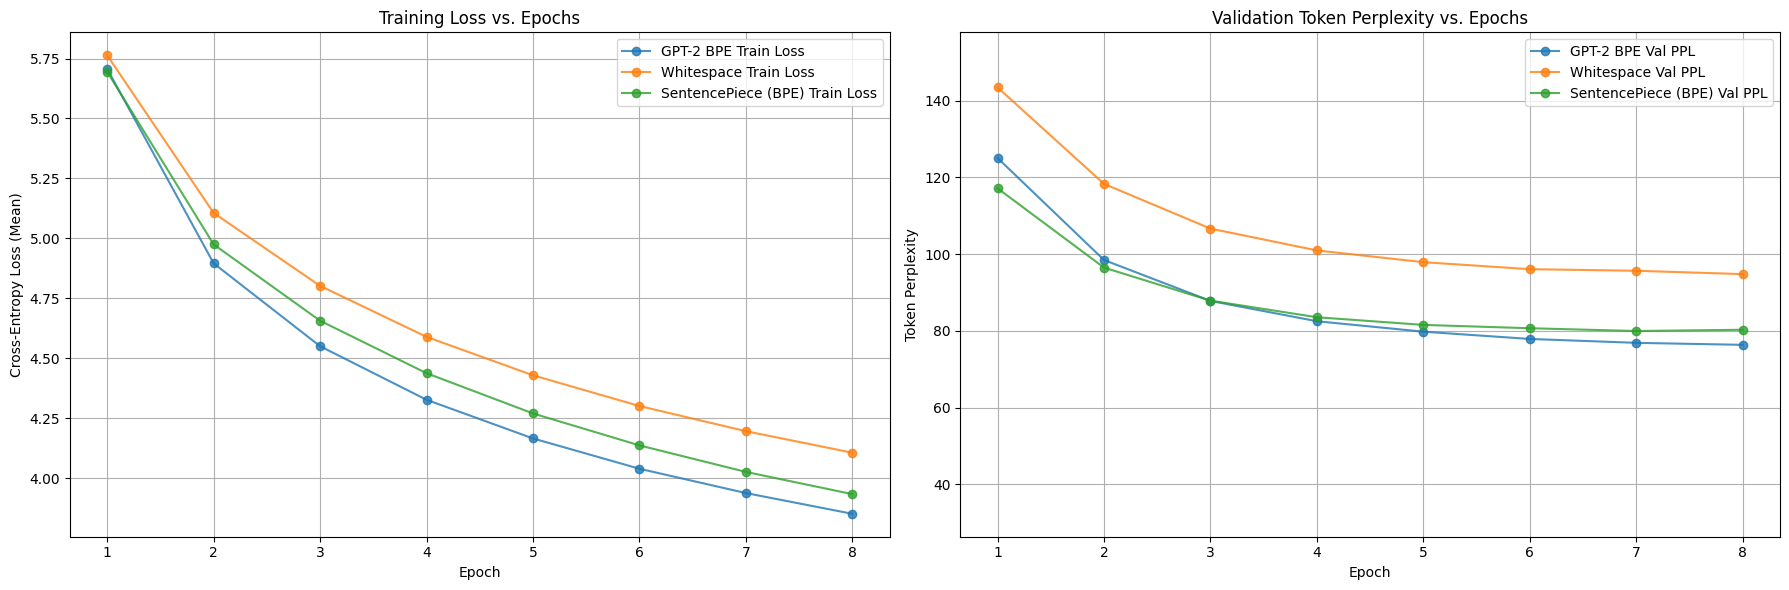

In [23]:
def plot_results(results: Dict[str, Any]):
    num_tokenizers = len(results)
    if num_tokenizers == 0:
        return

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

    for name, res in results.items():
        if not res.get("plots"):
            continue

        train_losses = res["plots"].get("train_loss", [])
        val_ppls = res["plots"].get("val_ppl", [])

        epochs_range = range(1, len(train_losses) + 1)

        if train_losses:
            ax1.plot(
                epochs_range,
                train_losses,
                label=f"{name} Train Loss",
                marker="o",
                alpha=0.8,
            )

        if val_ppls:
            ax2.plot(
                epochs_range, val_ppls, label=f"{name} Val PPL", marker="o", alpha=0.8
            )

    ax1.set_title("Training Loss vs. Epochs")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Cross-Entropy Loss (Mean)")
    ax1.legend()
    ax1.grid(True)
    ax1.set_xticks(range(1, EPOCHS + 1))

    ax2.set_title("Validation Token Perplexity vs. Epochs")
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Token Perplexity")
    ax2.legend()
    ax2.grid(True)
    ax2.set_xticks(range(1, EPOCHS + 1))

    all_ppls = [
        ppl
        for res in results.values()
        for ppl in res.get("plots", {}).get("val_ppl", [])
        if ppl
    ]
    if all_ppls:
        max_ppl = max(all_ppls)
        min_ppl = min(all_ppls)
        ax2.set_ylim(bottom=max(0, min_ppl - 50), top=min(max_ppl * 1.1, max_ppl + 200))

    plt.tight_layout()
    plt.show()


plot_results(results)

### 7.3. Qualitative Tokenization Analysis

In [24]:
qualitative_samples = [
    "This is a straightforward sentence for tokenization.",
    "However, things like 'supercalifragilisticexpialidocious' or 'tokenization' can be tricky.",
    "The U.S. government's policies from 2024 are complex.",
]

show_qualitative_examples(tokenizers_to_run, qualitative_samples)


Qualitative Tokenization Analysis

--- SAMPLE 1 ---
TEXT: "This is a straightforward sentence for tokenization."
------------------------------
TOKENIZER: GPT-2 BPE
  Tokens: 9 (Avg: 1.29 tok/word)
  Preview: [1212, 318, 257, 15836, 6827, 329, 11241, 1634, 13]
  Decoded: ['This', ' is', ' a', ' straightforward', ' sentence', ' for', ' token', 'ization', '.']
TOKENIZER: Whitespace
  Tokens: 8 (Avg: 1.14 tok/word)
  Preview: [40, 28, 14, 12466, 2144, 23, 0, 6]
  Decoded: ['this', 'is', 'a', 'straightforward', 'sentence', 'for', '<unk>', '.']
TOKENIZER: SentencePiece (BPE)
  Tokens: 9 (Avg: 1.29 tok/word)
  Preview: [585, 108, 7, 22819, 5264, 78, 39477, 2069, 50195]
  Decoded: ['▁This', '▁is', '▁a', '▁straightforward', '▁sentence', '▁for', '▁token', 'ization', '.']

--- SAMPLE 2 ---
TEXT: "However, things like 'supercalifragilisticexpialidocious' or 'tokenization' can be tricky."
------------------------------
TOKENIZER: GPT-2 BPE
  Tokens: 26 (Avg: 2.89 tok/word)
  Preview: [4864, 11, 1